In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.precision", 8)

# Use pre-processed csv
data_table = "../data/preprocessed_data.csv"
df = pd.read_csv(data_table, delimiter=",")

In [2]:
df = df[
    df["PubmedID"].notna() &
    df["Biomarker name"].notna() &
    df["HR_pick"].notna() &
    df["P_value_num"].notna()
].copy()

In [4]:
# get only studies that have investigated a unique biomarker that no other study has investigated
df["n_studies"] = (
    df.groupby("Biomarker name")["PubmedID"]
       .transform("nunique")
)

single_study = df[df["n_studies"] == 1].copy()

In [5]:
bio_summary = (
    df[df["n_studies"] == 1]
    .groupby("Biomarker name")
    .agg(
        ever_significant=("P_value_num", lambda x: (x < 0.05).any()),
        min_p=("P_value_num", "min"),
        n_rows=("P_value_num", "size")
    )
    .reset_index()
)

In [7]:
single_study_not_sig = bio_summary[~bio_summary["ever_significant"]]
print(single_study_not_sig.shape[0])
single_study_not_sig.sort_values("min_p")

61


,Biomarker name,ever_significant,min_p,n_rows
37,CK2α,False,0.050,1
125,p21,False,0.054,1
42,DKK1/p63,False,0.054,3
109,SRC,False,0.055,1
120,miR-421,False,0.058,1
...,...,...,...,...
47,EPHA3,False,0.800,1
0,5hmC,False,0.820,1
53,FBXW7,False,0.900,1
70,HRAS,False,0.900,1


In [8]:
single_study = single_study[single_study["P_value_num"] < 0.05].copy()

single_study["n_rows_within_study"] = (
    single_study
    .groupby(["PubmedID", "Biomarker name"])["HR_pick"]
    .transform("size")
)
single_study["n_rows_within_study"].value_counts()

n_rows_within_study
1    52
2    24
6    18
3     9
5     5
4     4
Name: count, dtype: int64

In [9]:
plot_tbl = (
    single_study
    .groupby("Biomarker name")
    .agg(
        n_rows=("n_rows_within_study", "max"),
        HR_median=("HR_pick", "median"),
        HR_q25=("HR_pick", lambda x: x.quantile(0.25)),
        HR_q75=("HR_pick", lambda x: x.quantile(0.75)),
        p_median=("P_value_num", "median")
    )
    .reset_index()
)

plot_tbl = plot_tbl.sort_values("HR_median")
plot_tbl["neglog10_p"] = -np.log10(plot_tbl["p_median"])

In [10]:
zero_p = plot_tbl[plot_tbl["p_median"].fillna(np.nan).eq(0)]
# zero_p[["Biomarker name", "p_median", "HR_median"]]
zero_p

,Biomarker name,n_rows,HR_median,HR_q25,HR_q75,p_median,neglog10_p


In [59]:
print(f"{plot_tbl.shape[0]} unique biomarkers investigated in only one study")

72 unique biomarkers investigated in only one study


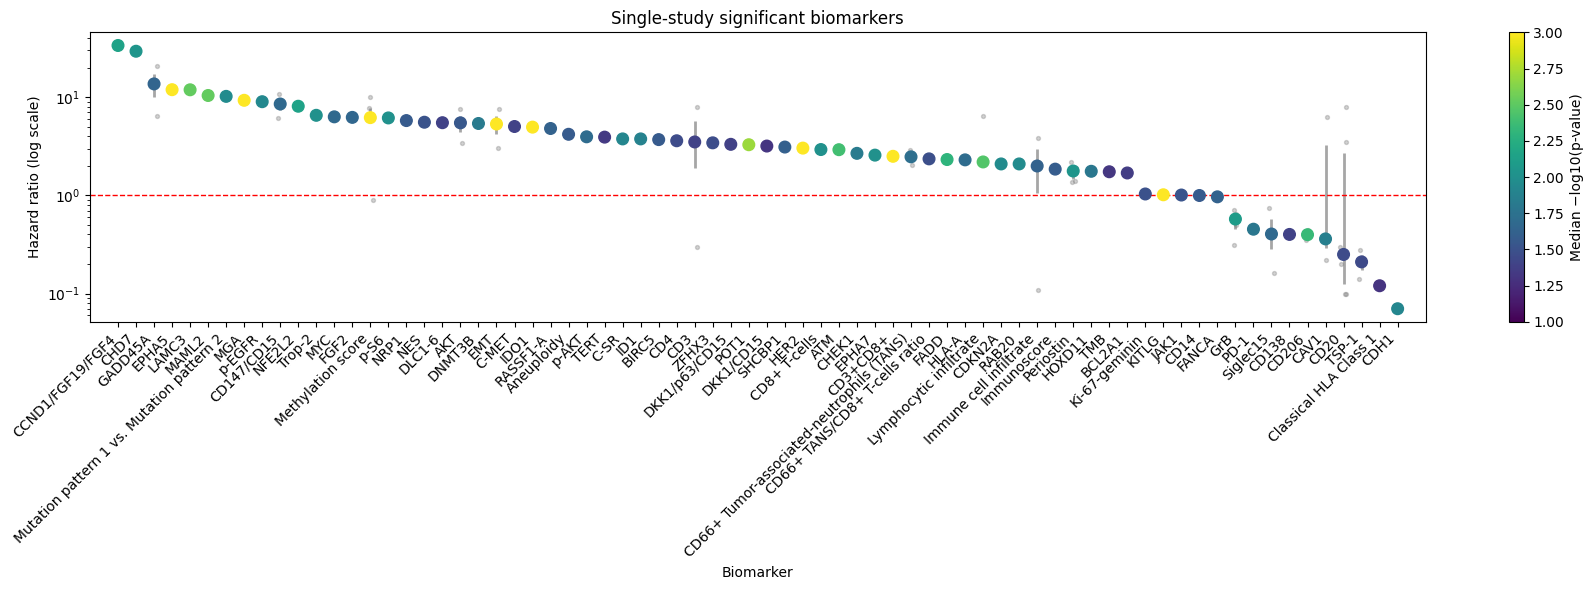

In [12]:
fig, ax = plt.subplots(
    figsize=(18, 6)
)

x = np.arange(len(plot_tbl))

plot_tbl = plot_tbl.sort_values("HR_median", ascending=False).reset_index(drop=True)
bio_order = plot_tbl["Biomarker name"].tolist()
bio_to_x = {b: i for i, b in enumerate(bio_order)}

# Add x positions to the row-level table
pts = single_study[single_study["Biomarker name"].isin(bio_order)].copy()
pts["x"] = pts["Biomarker name"].map(bio_to_x).astype(float)

# only biomarkers with multiple within-study estimates
multi_bios = plot_tbl.loc[plot_tbl["n_rows"] > 1, "Biomarker name"]
pts_multi = pts[pts["Biomarker name"].isin(multi_bios)].copy()

rng = np.random.default_rng(0)
pts_multi["x_jit"] = pts_multi["x"] + rng.uniform(-0.18, 0.18, size=len(pts_multi))

# --- Forest bars ---
forest_mask = plot_tbl["n_rows"] > 1

ax.vlines(
    x=x[forest_mask],
    ymin=plot_tbl.loc[forest_mask, "HR_q25"],
    ymax=plot_tbl.loc[forest_mask, "HR_q75"],
    color="grey",
    linewidth=2,
    alpha=0.7
)

ax.scatter(
    pts_multi["x_jit"],
    pts_multi["HR_pick"],
    color="gray",
    alpha=0.35,
    s=8,
    zorder=1,
)

# --- Median HR dots (colored by −log10(p)) ---
sc = ax.scatter(
    x,
    plot_tbl["HR_median"],
    c=plot_tbl["neglog10_p"],
    cmap="viridis",
    s=70,
    zorder=3,
    vmin=1, vmax=3
)

# Reference line at HR = 1
ax.axhline(1, linestyle="--", color="red", linewidth=1)

# Axes + scales
ax.set_yscale("log")
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin + 2, xmax - 2)

ax.set_xticks(x)
ax.set_xticklabels(plot_tbl["Biomarker name"], rotation=45, ha="right")
ax.set_xlabel("Biomarker")
ax.set_ylabel("Hazard ratio (log scale)")
ax.set_title("Single-study significant biomarkers")

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Median −log10(p-value)")

plt.savefig("figures/single-study_biomarkers.pdf", bbox_inches="tight")
plt.savefig("figures/single-study_biomarkers.png", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

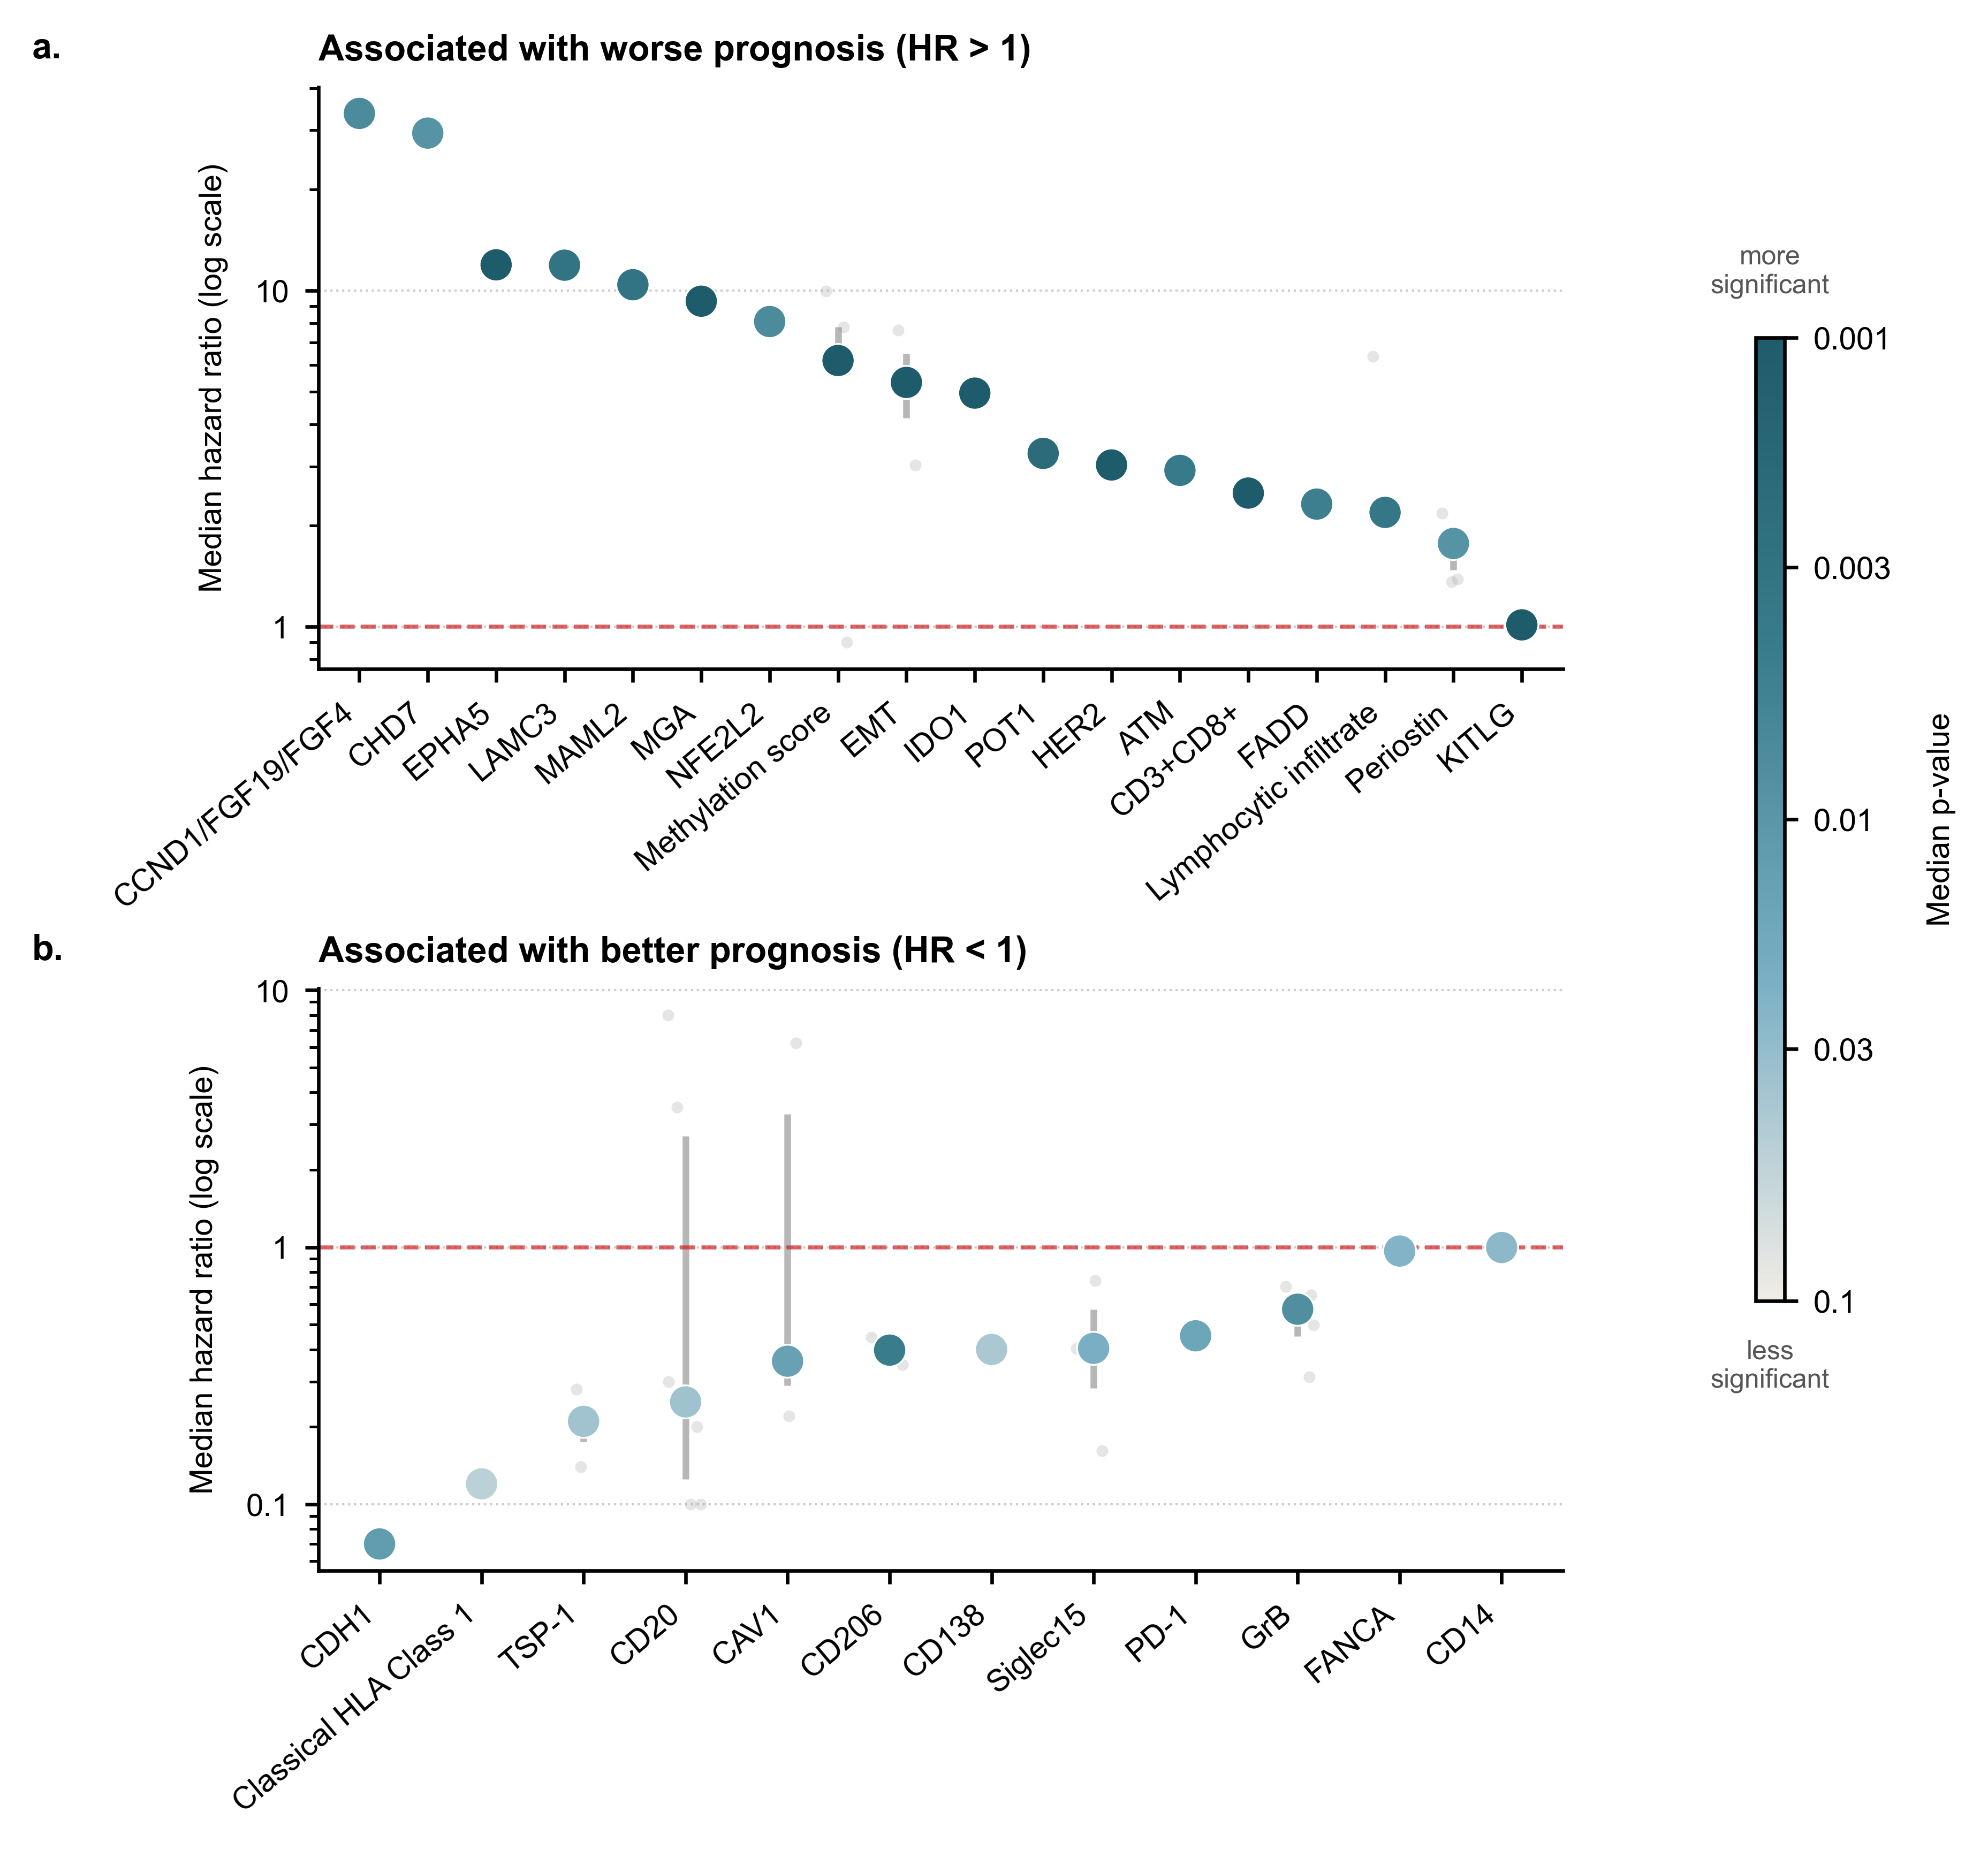

In [57]:
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

# Style: Arial/Helvetica
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "xtick.labelsize":    7,
    "ytick.labelsize":    7,
    "axes.titlesize":     8,
    "axes.titleweight":   "bold",
    "axes.labelsize":     7,
    "figure.dpi":         600,
})

# Data prep
plot_tbl_low_p = plot_tbl[plot_tbl["p_median"] < 0.01].copy()

tbl_hi = plot_tbl_low_p[plot_tbl_low_p["HR_median"] > 1].copy()
tbl_lo = plot_tbl[plot_tbl["HR_median"] < 1].copy()

tbl_hi = tbl_hi.sort_values("HR_median", ascending=False).reset_index(drop=True)
tbl_lo = tbl_lo.sort_values("HR_median", ascending=True).reset_index(drop=True)

# Colormap
vmin, vmax = 1, 3   # neglog10 range → p in [0.001, 0.1]
clean_p_values     = [0.001, 0.003, 0.01, 0.03, 0.1]
cbar_ticks_neglog  = [-np.log10(p) for p in clean_p_values]   # tick positions
cbar_tick_labels   = ["0.001", "0.003", "0.01", "0.03", "0.1"]
clinical_teal = LinearSegmentedColormap.from_list(
    "clinical_teal",
    ["#f0ece6", "#7aafc4", "#3a7d8c", "#1f5c6b"]
)

# Figure
fig, axes = plt.subplots(
    nrows=2,
    figsize=(5, 6),
    sharey=False,
    gridspec_kw={"hspace": 0.55}
)

panel_letters = ["a.", "b."]
panel_titles  = [
    "Associated with worse prognosis (HR > 1)",
    "Associated with better prognosis (HR < 1)",
]
sc_last = None

for ax, tbl, title, letter in zip(axes, [tbl_hi, tbl_lo], panel_titles, panel_letters):

    ax.text(-0.23, 1.095, letter, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top")

    if tbl.empty:
        ax.set_axis_off()
        ax.set_title(f"{title}\n(no biomarkers)", loc="left", pad=10)
        continue

    x          = np.arange(len(tbl))
    bio_order  = tbl["Biomarker name"].tolist()
    bio_to_x   = {b: i for i, b in enumerate(bio_order)}

    pts = single_study[single_study["Biomarker name"].isin(bio_order)].copy()
    pts["x"] = pts["Biomarker name"].map(bio_to_x).astype(float)

    multi_bios = tbl.loc[tbl["n_rows"] > 1, "Biomarker name"]
    pts_multi  = pts[pts["Biomarker name"].isin(multi_bios)].copy()

    rng = np.random.default_rng(0)
    pts_multi = pts_multi.copy()
    pts_multi["x_jit"] = pts_multi["x"] + rng.uniform(-0.18, 0.18, size=len(pts_multi))

    forest_mask = tbl["n_rows"] > 1
    ax.vlines(
        x=x[forest_mask],
        ymin=tbl.loc[forest_mask, "HR_q25"],
        ymax=tbl.loc[forest_mask, "HR_q75"],
        color="#888888", linewidth=1.5, alpha=0.6, zorder=2,
    )

    ax.scatter(
        pts_multi["x_jit"], pts_multi["HR_pick"],
        color="#aaaaaa", alpha=0.3, s=7, linewidths=0, zorder=1,
    )

    sc = ax.scatter(
        x, tbl["HR_median"],
        c=tbl["neglog10_p"],
        cmap=clinical_teal,
        s=55,
        linewidths=0.4,
        edgecolors="white",
        zorder=3,
        vmin=vmin, vmax=vmax,
    )
    sc_last = sc

    ax.axhline(1, linestyle="--", color="#CC2222", linewidth=0.9, alpha=0.7)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))

    ax.set_xticks(x)
    ax.set_xticklabels(tbl["Biomarker name"], rotation=40, ha="right", fontsize=7)
    ax.set_title(title, loc="left", pad=6)
    ax.set_xlim(-0.6, len(tbl) - 0.4)
    ax.set_ylabel("Median hazard ratio (log scale)", labelpad=6)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
    ax.xaxis.grid(False)

# Colorbar
cax  = fig.add_axes([1.02, 0.25, 0.018, 0.5])
cbar = fig.colorbar(sc_last, cax=cax)

cbar.set_ticks(cbar_ticks_neglog)
cbar.set_ticklabels(cbar_tick_labels)
cbar.ax.tick_params(labelsize=7)
cbar.set_label("Median p-value", fontsize=7, labelpad=8)

cbar.ax.text(0.5,  1.04, "more\nsignificant", ha="center", va="bottom",
             transform=cbar.ax.transAxes, fontsize=6, color="#555555")
cbar.ax.text(0.5, -0.04, "less\nsignificant", ha="center", va="top",
             transform=cbar.ax.transAxes, fontsize=6, color="#555555")

# Save
plt.savefig(
    "figures/single-study_biomarkers_split_hr_direction.pdf",
    bbox_inches="tight",
    facecolor="white",
)
plt.savefig(
    "figures/single-study_biomarkers_split_hr_direction.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()